<img src="MUML_header.svg" alt="Header" style="width:100%; height:auto;">

# 01_03 Decision trees 


## 1. Decision trees

### Step 1: Train a baseline Decision Tree on Breast Cancer

We’ll start with a real, tabular dataset ([Breast Cancer Wisconsin](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset)). 

**What to do**
1. Load the dataset with [`load_breast_cancer()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html). 
2. Split into train/test (70/30) with `train_test_split(..., random_state=42, stratify=y)`.
3. Create `DecisionTreeClassifier(random_state=42)` and train it on the training set.
4. Print training and test accuracies.
5. Keep `feature_names` and `class_names` handy (we’ll use them for visualization).


In [31]:
#1. Load the dataset with [`load_breast_cancer()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html). 
import pandas as pd
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

display(pd.DataFrame(data.data, columns=data.feature_names).head())  # Display the dataset description
#2. Split into train/test (70/30) with `train_test_split(..., random_state=42, stratify=y)`.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, random_state=42, stratify=data.target)

#3. Create `DecisionTreeClassifier(random_state=42)` and train it on the training set.
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
#4. Print training and test accuracies.
train_accuracy = tree.score(X_train, y_train)
test_accuracy = tree.score(X_test, y_test)
print(f"Training accuracy: {train_accuracy:.2%}")
print(f"Test accuracy: {test_accuracy:.2%}")
#5. Keep `feature_names` and `class_names` handy (we’ll use them for visualization).
feature_names = data.feature_names
class_names = data.target_names


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Training accuracy: 100.00%
Test accuracy: 91.81%


### Step 2: Depth vs. performance

Tree depth controls model complexity: too shallow → **underfitting**; too deep → **overfitting**. We’ll sweep `max_depth` and observe train/test accuracy.

**What to do**
1. For `max_depth` from 1 to 15, fit a `DecisionTreeClassifier`.
2. Record train and test accuracy for each depth.
3. Plot both curves (accuracy vs `max_depth`) on the same axes.

Note that when the depth is too shallow (underfitting), both accuracies are low, whereas when the depth is too deep (overfitting), there is a big gap between them.

Max depth: 1, Training accuracy: 92.71%, Test accuracy: 91.23%
Max depth: 2, Training accuracy: 96.48%, Test accuracy: 91.81%
Max depth: 3, Training accuracy: 97.99%, Test accuracy: 92.40%
Max depth: 4, Training accuracy: 99.25%, Test accuracy: 92.40%
Max depth: 5, Training accuracy: 99.50%, Test accuracy: 92.98%
Max depth: 6, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 7, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 8, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 9, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 10, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 11, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 12, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 13, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 14, Training accuracy: 100.00%, Test accuracy: 91.81%
Max depth: 15, Training accuracy: 100.00%, Test accuracy: 91.81%


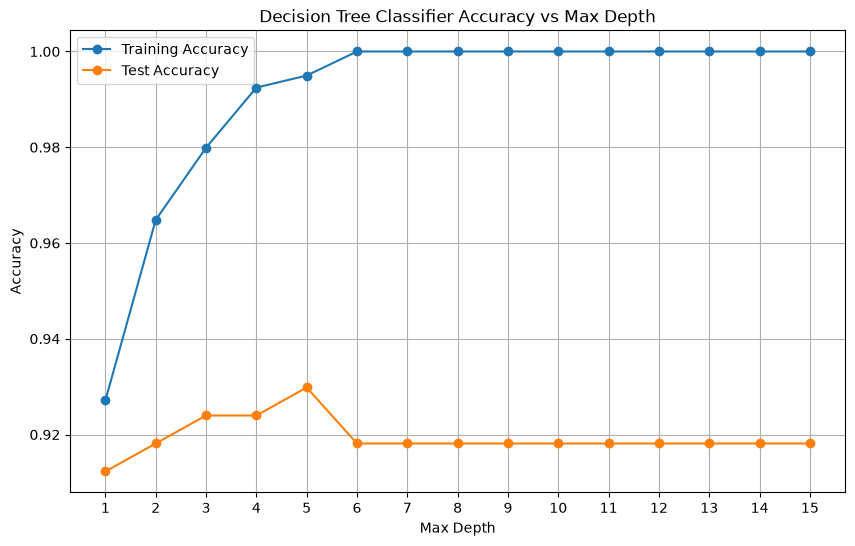

In [32]:
import numpy as np
import matplotlib.pyplot as plt

max_depths = np.arange(1, 16)
train_accuracies = []
test_accuracies = []
for max_depth in max_depths:
    dtc = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dtc.fit(X_train, y_train)
    train_accuracy = dtc.score(X_train, y_train)
    test_accuracy = dtc.score(X_test, y_test)
    print(f"Max depth: {max_depth}, Training accuracy: {train_accuracy:.2%}, Test accuracy: {test_accuracy:.2%}")

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(max_depths, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Classifier Accuracy vs Max Depth')
plt.xticks(max_depths)
plt.legend()
plt.grid()




### Step 3: Visualize the learned tree (structure and rules)

Small trees are easy to inspect and explain. Scikit-learn gives us two useful tools:

- **`plot_tree`**: draws the full tree diagram.  
  - Each node shows the feature, threshold, impurity, number of samples, and class distribution.  
   
- **`export_text`**: prints the tree as **if–else rules** in plain text.  
  - Each line corresponds to a split, with indentation for tree depth.  
  - Useful if you want to see decision rules without a graphic. 

**What to do**
1. Train a tree with `max_depth=3`.
2. Use `plot_tree(...)` with `feature_names`, `class_names`, `filled=True`, `rounded=True`.
3. Use `export_text(tree, feature_names=...)` to print readable “if–else” rules.

Note which features appear near the root (they typically carry more information).


|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- smoothness error <= 0.00
|   |   |   |--- class: 1
|   |   |--- smoothness error >  0.00
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 23.74
|   |   |   |--- class: 1
|   |   |--- worst texture >  23.74
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.45
|   |   |--- class: 1
|   |--- texture error >  0.45
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



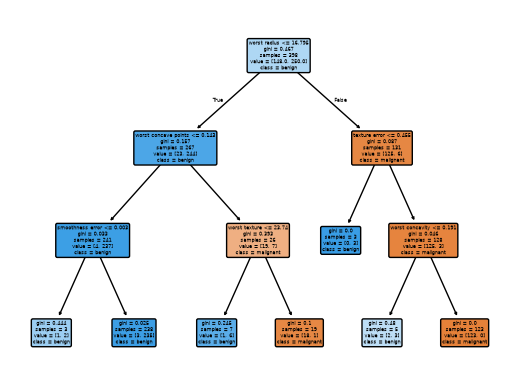

In [33]:
max_depth = 3

dtc = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
dtc.fit(X_train, y_train)
from sklearn.tree import plot_tree
plot_tree(dtc, feature_names=feature_names, class_names=class_names, filled=True, rounded=True)
from sklearn.tree import export_text
tree_rules = export_text(dtc, feature_names=list(feature_names))
print(tree_rules)

### Step 4: Inspect feature importances

Trees compute global feature importances (`.feature_importances_`) based on impurity reduction. This gives a quick sense of which features the model relied on most.

**What to do**
1. Access `tree.feature_importances_` (from your baseline in Step 1.1).
2. Sort importances in a descending order and plot a horizontal bar chart with feature names.

Which features matter, which seem negligible?


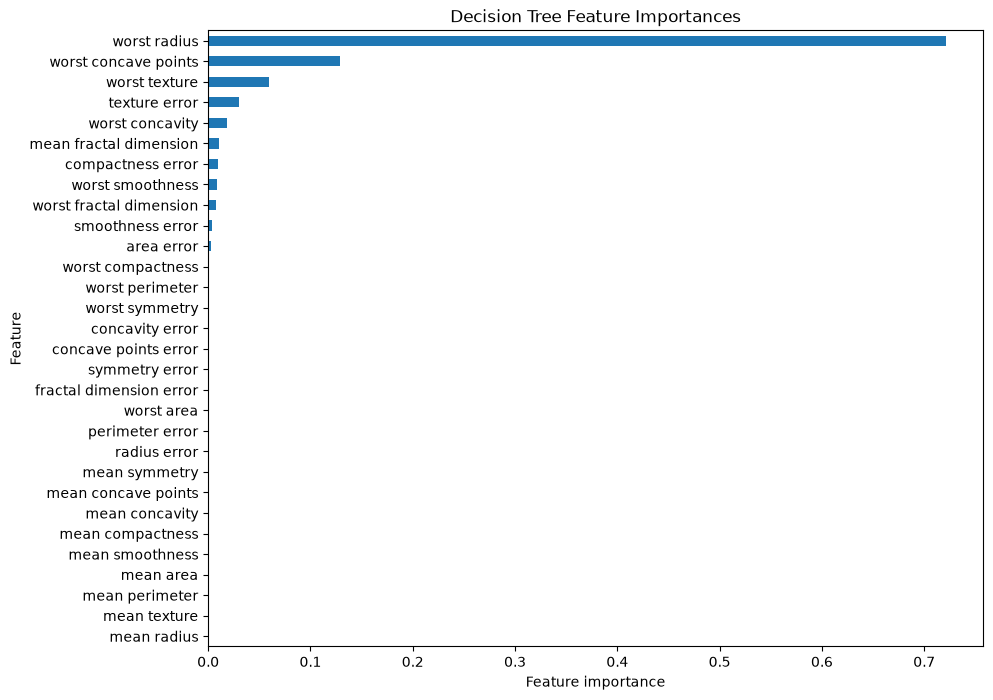

In [47]:
# Get feature importances
importances = tree.feature_importances_

# Create a Series with feature names
feature_importances = pd.Series(
    importances,
    index=feature_names
)

# Sort from smallest to largest
feature_importances = feature_importances.sort_values()

# Plot
feature_importances.plot(
    kind="barh",
    figsize=(10, 8)
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importances")
plt.show()


### Step 5: Visualize decision boundaries on a 2D dataset

To build geometric intuition, we’ll use a synthetic 2D dataset (`make_moons`) and plot decision regions. To that end, we'll use the following function:

- **`contourf`**: draws filled contour plots.  
  - We’ll create a dense grid of (x1, x2) points, use the model to predict their classes,  
  - Then color the grid with `plt.contourf(...)` — each color is a predicted class region.  

**Note:** We will use the moons dataset for visualization but keep the Breast Cancer dataset for further exploration.

**What to do**
1. Generate moons with `make_moons(n_samples=400, noise=0.25, random_state=0)`.  
2. Split into train/test (70/30, stratify target).  
3. Train two trees:  
   - Shallow: `max_depth=2`  
   - Deeper: `max_depth=6`  
4. On a dense grid, predict with each tree and plot the background regions with `contourf`.  
5. After coloring the background, plot the actual training points (scatter).   
6. Compare: the shallow tree is simple but suffers from underfitting; the deep tree captures more detail but may overfit.  


X shape: (400, 2), y shape: (400,)


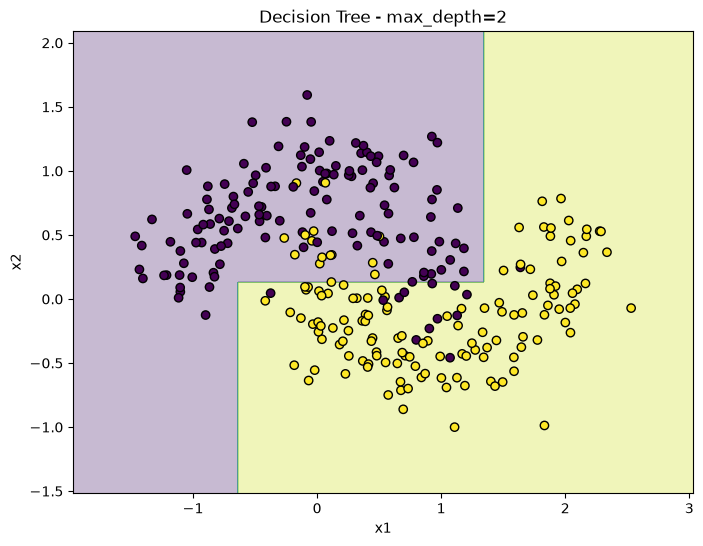

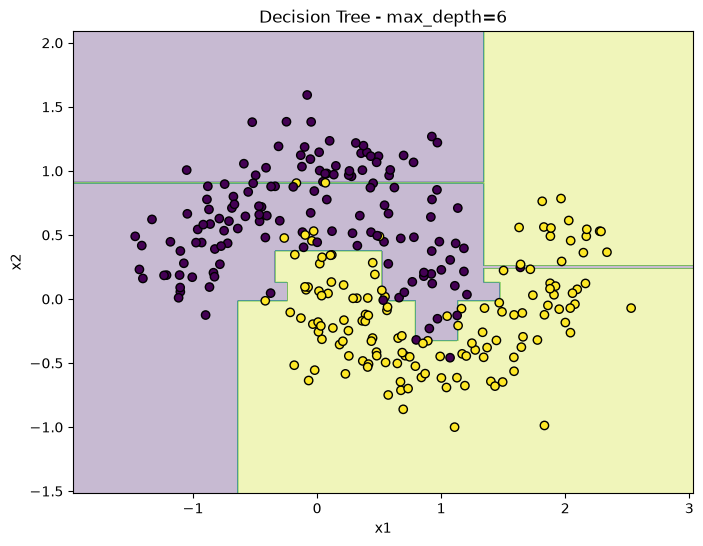

In [76]:
from sklearn.datasets import make_moons
# 1. Generate the moons dataset
X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=0
)

print(f"X shape: {X.shape}, y shape: {y.shape}")

# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=0
)

# 3. Train two decision trees
tree_shallow = DecisionTreeClassifier(
    max_depth=2,
    random_state=0
)

tree_deep = DecisionTreeClassifier(
    max_depth=6,
    random_state=0
)

tree_shallow.fit(X_train, y_train)
tree_deep.fit(X_train, y_train)

# Create a dense grid
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Convert the grid into a list of (x1, x2) points
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for every point in the grid
Z_shallow = tree_shallow.predict(grid)
Z_deep = tree_deep.predict(grid)

# Reshape predictions to the shape of the grid
Z_shallow = Z_shallow.reshape(xx.shape)
Z_deep = Z_deep.reshape(xx.shape)




# Shallow tree
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z_shallow, alpha=0.3)
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor="k"
)

plt.title("Decision Tree - max_depth=2")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Deep tree
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z_deep, alpha=0.3)
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolor="k"
)

plt.title("Decision Tree - max_depth=6")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()


